In [1]:
import numpy as np
import matplotlib.pyplot as plt


from thermosim.utils.io import load_irb_txt

In [2]:
arr, settings, params = load_irb_txt("../data/test/große Lochplatte_front_0002.csv")
print("Data shape:", arr.shape)
print("Settings:", settings)
print("Params:", params)

Data shape: (385, 485)
Settings: {'Version': 3, 'ImageWidth': 485, 'ImageHeight': 385, 'ShotRange': [22.4, 26.4], 'CalibRange': [-40.15, 119.85], 'TempUnit': '°C', 'StartPos': [64, 48], 'EndPos': [548, 432]}
Params: {'Filename': 'große Lochplatte_front_0002.irb', 'FrameIndex': 2, 'RecDate': '05.12.2025', 'RecTime': '11:30:30', 'ms': 59998.0}


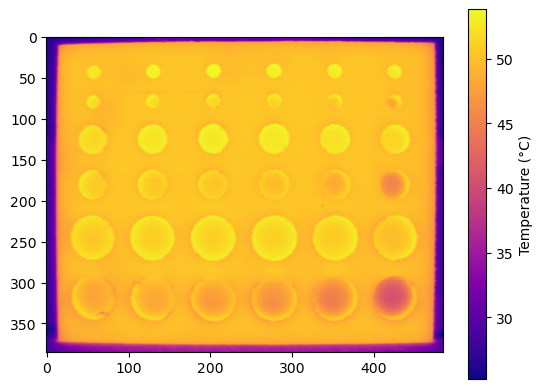

In [3]:
plt.imshow(arr, cmap="plasma")
plt.colorbar(label="Temperature (°C)")

In [4]:
import cv2
def undistort_image(img, K, dist, alpha=0.0):
    """
    alpha=0.0 -> crop to valid pixels (no black border)
    alpha=1.0 -> keep all pixels (more black border)
    """
    h, w = img.shape[:2]
    newK, roi = cv2.getOptimalNewCameraMatrix(K, dist, (w, h), alpha, (w, h))
    und = cv2.undistort(img, K, dist, None, newK)
    return und, newK, roi

Text(0.5, 1.0, 'original')

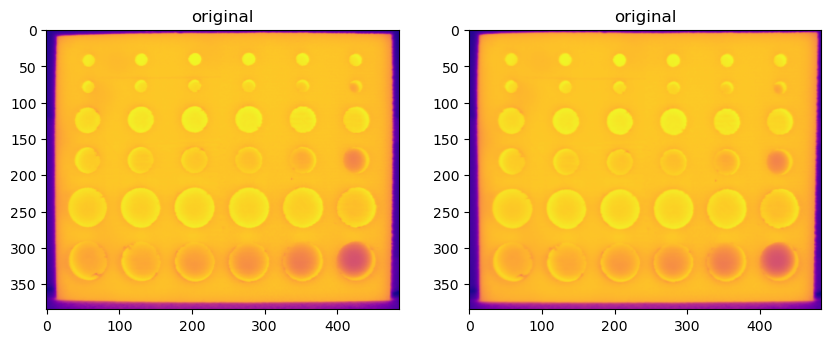

In [16]:
K = np.array([
    [1.35362148e+03, 0.00000000e+00, 3.39004384e+02],
    [0.00000000e+00, 1.35100165e+03, 3.27834879e+02],
    [0.00000000e+00, 0.00000000e+00, 1.00000000e+00]
], dtype=np.float64)

dist = np.array([
    -2.69837225e-01,
    -5.75291287e+00,
    -1.74221496e-02,
    -1.47559733e-02,
    4.11124356e+01
], dtype=np.float64)

img_, _, _  = undistort_image(arr,K,dist)

fig, ax = plt.subplots(1,2,figsize = (10,5))

ax[0].imshow(arr,cmap = "plasma")
ax[0].set_title("original")
ax[1].imshow(img_,cmap="plasma")
ax[1].set_title("original")

In [6]:
import plotly.express as px
fig = px.imshow(arr, color_continuous_scale="plasma",title="Temperature")
fig.show()